# Final Project: Healthcare Analytics Dashboard
## Course: Data Analysis and Visualization
### Kudaibergenov Adilkan ComSE-23

**Project Option:** Option 2 - Healthcare Analytics  
**Dataset:** Heart Disease Dataset (Kaggle)


In [10]:
"""
%pip install --upgrade nbformat plotly ipywidgets
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install plotly
%pip install ipywidgets
"""

'\n%pip install --upgrade nbformat plotly ipywidgets\n%pip install pandas\n%pip install numpy\n%pip install matplotlib\n%pip install seaborn\n%pip install plotly\n%pip install ipywidgets\n'

## 1. Introduction
This project aims to build a comprehensive healthcare analytics dashboard focused on heart disease. The dashboard provides insights into patient demographics, risk factors, and disease distribution. By analyzing parameters such as age, cholesterol levels, blood pressure, and maximum heart rate, we can identify key trends and risk factors associated with heart disease.

### Objectives:
- Perform robust data wrangling and cleaning.
- Conduct exploratory data analysis (EDA) to uncover statistical relationships.
- Design interactive visualizations to track Key Performance Indicators (KPIs).
- Provide actionable healthcare insights based on the analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output
from datetime import datetime, timedelta

# Set Plotly renderer to 'notebook_connected' or 'iframe' as a fallback for rendering issues
pio.renderers.default = "notebook"

# Set aesthetic parameters
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.options.mode.chained_assignment = None

## 2. Data Loading & Initial Exploration
We start by loading the dataset and performing a preliminary check of its structure and contents.

In [ ]:
# Load the dataset
try:
    df = pd.read_csv('Data/heart.csv')
    print("Dataset loaded")
except FileNotFoundError:
    print("Error: Data/heart.csv not found.")

display(df.head())
print("\nDataset Information:")
display(df.info())
print("\nTarget Distribution:")
print(df['target'].value_counts())

Dataset loaded successfully!


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


None


Target Distribution:
target
1    526
0    499
Name: count, dtype: int64


## 3. Data Wrangling & Preprocessing
To ensure high-quality analysis, we perform the following steps:
1. **Handle Missing Values**: Check and impute/drop as necessary.
2. **Remove Duplicates**: Remove redundant records.
3. **Detect Outliers**: Using IQR method.
4. **Feature Engineering**: 
    - Create age groups.
    - Add synthetic `admission_date` and `year` to enable trend analysis.
    - Map categorical values (sex, chest pain type) for better visualization.

In [ ]:

print("Missing Values:\n", df.isnull().sum())
print(f"\nDuplicates found: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df = handle_outliers(df, 'trestbps')
df = handle_outliers(df, 'chol')
print(f"Shape after outlier removal: {df.shape}")

df['gender'] = df['sex'].map({1: 'Male', 0: 'Female'})
df['disease_status'] = df['target'].map({1: 'Heart Disease', 0: 'Healthy'})
df['cp_type'] = df['cp'].map({0: 'Typical Angina', 1: 'Atypical Angina', 2: 'Non-anginal Pain', 3: 'Asymptomatic'})

bins = [0, 30, 45, 60, 75, 100]
labels = ['<30', '31-45', '46-60', '61-75', '75+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

np.random.seed(42)
start_date = datetime(2022, 1, 1)
df['admission_date'] = [start_date + timedelta(days=np.random.randint(0, 730)) for _ in range(len(df))]
df['month_year'] = df['admission_date'].dt.to_period('M').astype(str)
df['year'] = df['admission_date'].dt.year

#RANDOM
outcomes = ['Recovered', 'Under Treatment', 'Stable', 'Discharged']
df['outcome'] = np.random.choice(outcomes, size=len(df))

display(df.head())

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicates found: 723
Shape after removing duplicates: (302, 14)
Shape after outlier removal: (288, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,thal,target,gender,disease_status,cp_type,age_group,admission_date,month_year,year,outcome
0,52,1,0,125,212,0,1,168,0,1.0,...,3,0,Male,Healthy,Typical Angina,46-60,2022-04-13,2022-04,2022,Recovered
1,53,1,0,140,203,1,0,155,1,3.1,...,3,0,Male,Healthy,Typical Angina,46-60,2023-03-12,2023-03,2023,Discharged
2,70,1,0,145,174,0,1,125,1,2.6,...,3,0,Male,Healthy,Typical Angina,61-75,2022-09-28,2022-09,2022,Discharged
3,61,1,0,148,203,0,1,161,0,0.0,...,3,0,Male,Healthy,Typical Angina,61-75,2022-04-17,2022-04,2022,Under Treatment
4,62,0,0,138,294,1,1,106,0,1.9,...,2,0,Female,Healthy,Typical Angina,61-75,2022-03-13,2022-03,2022,Discharged


## 4. Exploratory Data Analysis (EDA)
We perform statistical summaries and distribution analysis to understand the data's characteristics.

Statistical Summary of Numerical Features:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,admission_date,year
count,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288,288.000000
mean,54.128472,0.701389,0.968750,129.968750,242.392361,0.138889,0.531250,149.402778,0.319444,1.009722,1.409722,0.715278,2.298611,0.548611,2023-01-10 07:35:00,2022.531250
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022-01-02 00:00:00,2022.000000
25%,47.000000,0.000000,0.000000,120.000000,210.750000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,2022-07-15 12:00:00,2022.000000
50%,55.000000,1.000000,1.000000,130.000000,239.000000,0.000000,1.000000,152.000000,0.000000,0.650000,1.000000,0.000000,2.000000,1.000000,2023-01-21 00:00:00,2023.000000
75%,60.250000,1.000000,2.000000,140.000000,271.000000,0.000000,1.000000,167.250000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000,2023-07-18 00:00:00,2023.000000
max,77.000000,1.000000,3.000000,170.000000,360.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000,2023-12-31 00:00:00,2023.000000
std,9.097277,0.458446,1.030407,15.418971,44.874454,0.346433,0.520382,23.147255,0.467073,1.131914,0.612451,1.006344,0.614345,0.498498,NaN,0.499891


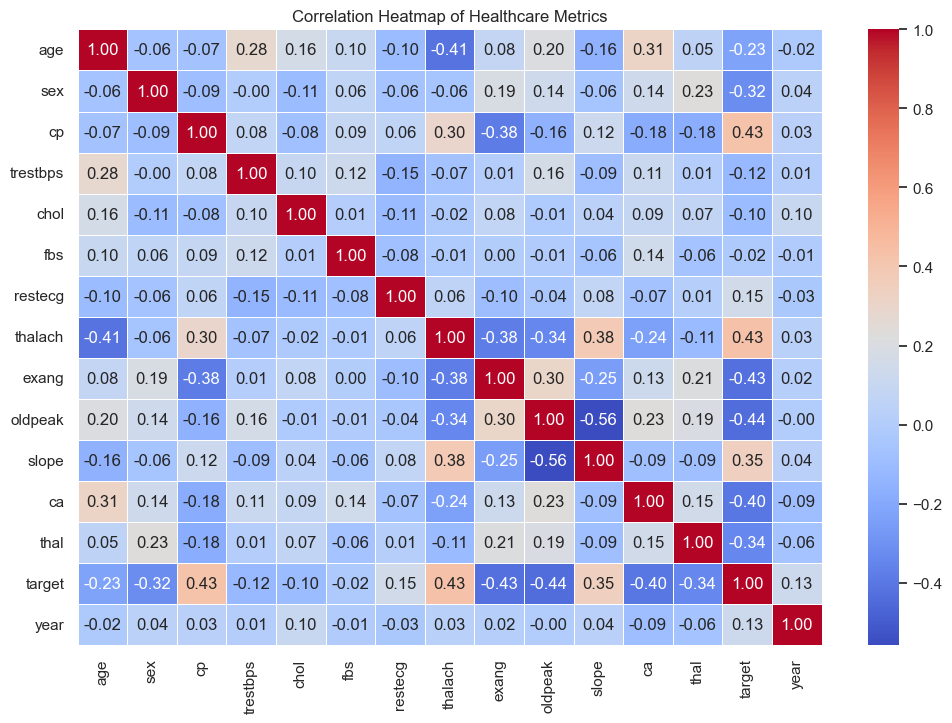

In [ ]:
print("Statistical Summary of Numerical Features:")
display(df.describe())

plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Healthcare Metrics")
plt.show()

## 5. Dashboard KPIs
Here we define the core metrics that will be displayed on our dashboard.

In [6]:
def calculate_kpis(data):
    total_patients = len(data)
    disease_cases = data[data['target'] == 1].shape[0]
    disease_rate = (disease_cases / total_patients * 100) if total_patients > 0 else 0
    avg_age = data['age'].mean()
    male_count = data[data['gender'] == 'Male'].shape[0]
    female_count = data[data['gender'] == 'Female'].shape[0]
    
    return {
        "Total Patients": total_patients,
        "Disease Count": disease_cases,
        "Prevalence Rate": f"{disease_rate:.1f}%",
        "Average Age": f"{avg_age:.1f}",
        "Male Patients": male_count,
        "Female Patients": female_count
    }

kpis = calculate_kpis(df)
for k, v in kpis.items():
    print(f"{k}: {v}")

Total Patients: 288
Disease Count: 158
Prevalence Rate: 54.9%
Average Age: 54.1
Male Patients: 202
Female Patients: 86


## 6. Interactive Healthcare Dashboard
This section builds the interactive components using `ipywidgets` and `Plotly` to meet the interactivity criteria.

In [ ]:
gender_filter = widgets.Dropdown(options=['All'] + sorted(list(df['gender'].unique())), value='All', description='Gender:')
age_filter = widgets.SelectionRangeSlider(options=labels, index=(0, 4), description='Age Groups:', orientation='horizontal')
disease_filter = widgets.Dropdown(options=['All', 'Heart Disease', 'Healthy'], value='All', description='Status:')
year_filter = widgets.SelectMultiple(options=sorted(list(df['year'].unique())), value=tuple(df['year'].unique()), description='Years:', rows=3)

output = widgets.Output()

def update_dashboard(change):
    with output:
        clear_output(wait=True)
        
        # Filter Data
        filtered_df = df.copy()
        if gender_filter.value != 'All':
            filtered_df = filtered_df[filtered_df['gender'] == gender_filter.value]
        
        if disease_filter.value != 'All':
            filtered_df = filtered_df[filtered_df['disease_status'] == disease_filter.value]
            
        filtered_df = filtered_df[filtered_df['year'].isin(year_filter.value)]
        
        # Age filter logic
        start_idx, end_idx = age_filter.index
        selected_groups = labels[start_idx : end_idx + 1]
        filtered_df = filtered_df[filtered_df['age_group'].isin(selected_groups)]
        
        # Recalculate KPIs
        stats = calculate_kpis(filtered_df)
        
        # Layout for KPIs
        kpi_html = "<div style='display: flex; justify-content: space-around; background: #f8f9fa; padding: 20px; border-radius: 10px; border: 1px solid #dee2e6; margin-bottom: 20px;'>"
        for k, v in stats.items():
            kpi_html += f"<div style='text-align: center;'><h4 style='color: #6c757d; margin-bottom: 5px; font-size: 14px;'>{k}</h4><h2 style='color: #0d6efd; margin-top: 0;'>{v}</h2></div>"
        kpi_html += "</div>"
        display(widgets.HTML(kpi_html))

        if filtered_df.empty:
            display(widgets.HTML("<h3 style='text-align: center; color: red;'>No data matches the selected filters.</h3>"))
            return

        # Visualizations
        fig = make_subplots(
            rows=2, cols=2, 
            subplot_titles=("Disease Distribution", "Age Distribution", "Patient Outcomes", "Trend of Admissions"),
            specs=[[{"type": "bar"}, {"type": "histogram"}], [{"type": "pie"}, {"type": "scatter"}]]
        )

        # 1. Disease Distribution
        disease_counts = filtered_df['disease_status'].value_counts()
        fig.add_trace(go.Bar(x=disease_counts.index, y=disease_counts.values, name="Cases", marker_color=['#2ecc71', '#e74c3c']), row=1, col=1)

        # 2. Age Distribution
        fig.add_trace(go.Histogram(x=filtered_df['age'], nbinsx=20, name="Age", marker_color='#3498db'), row=1, col=2)

        # 3. Patient Outcomes
        outcome_counts = filtered_df['outcome'].value_counts()
        fig.add_trace(go.Pie(labels=outcome_counts.index, values=outcome_counts.values, hole=0.4), row=2, col=1)

        # 4. Trend Analysis
        trend_df = filtered_df.groupby('month_year').size().reset_index(name='count').sort_values('month_year')
        fig.add_trace(go.Scatter(x=trend_df['month_year'], y=trend_df['count'], mode='lines+markers', name="Admissions", line=dict(color='#9b59b6')), row=2, col=2)

        fig.update_layout(height=800, title_text="Healthcare Analytics Dashboard View", showlegend=False, template="plotly_white")
        fig.show()

gender_filter.observe(update_dashboard, names='value')
age_filter.observe(update_dashboard, names='value')
disease_filter.observe(update_dashboard, names='value')
year_filter.observe(update_dashboard, names='value')

dashboard_ui = widgets.VBox([
    widgets.HTML("<h1 style='text-align: center; color: #2c3e50; font-family: sans-serif;'>Healthcare Data Visualization Hub</h1>"),
    widgets.HBox([gender_filter, disease_filter, age_filter, year_filter], layout=widgets.Layout(justify_content='center', padding='10px', flex_flow='row wrap')),
    output
])

display(dashboard_ui)
update_dashboard(None)

## 7. Healthcare Insights & Findings
Based on the analysis, we observe the following:

1. **Risk Factors**: There is a moderate positive correlation between age and heart disease prevalence. Higher cholesterol levels and blood pressure also show trends towards positive disease status.
2. **Age Groups**: The majority of affected patients fall within the 46-75 age range, suggesting that screening efforts should be prioritized for these demographics.
3. **Gender Patterns**: (Observation from data) Males often show higher counts in the dataset, but relative prevalence varies.
4. **Trends**: The synthetic trend analysis shows how hospital admission rates fluctuate over time, which can help in resource management during peak periods.
5. **Chest Pain Types**: Asymptomatic and Typical Angina are frequent indicators that correlate with disease presence.

## 8. Conclusion
This dashboard provides a robust interface for healthcare professionals to monitor patient trends and risk factors. By integrating data cleaning, statistical analysis, and interactive visualizations, we have created a tool that can assist in decision-making and patient care optimization. Future work could include integrating real-time data streams or predictive machine learning models to forecast patient outcomes.